In [3]:
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.13 opencv-python



Found existing installation: mediapipe 0.10.13
Uninstalling mediapipe-0.10.13:
  Successfully uninstalled mediapipe-0.10.13
  Using cached mediapipe-0.10.13-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
Using cached mediapipe-0.10.13-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (35.6 MB)


In [4]:
from google.colab import files

uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print("Uploaded video:", video_path)

Saving IMG_2123.mov to IMG_2123.mov
Uploaded video: IMG_2123.mov


In [5]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Video, display

In [6]:
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError("Could not open uploaded video.")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = frame_count / fps if fps > 0 else 0

print(f"FPS: {fps}")
print(f"Frame count: {frame_count}")
print(f"Resolution: {width} x {height}")
print(f"Duration: {duration:.2f} seconds")

cap.release()

FPS: 24.0
Frame count: 525
Resolution: 2160 x 3840
Duration: 21.88 seconds


In [7]:
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

In [8]:
# Landmark indices
LEFT_MOUTH = 61
RIGHT_MOUTH = 291
UPPER_LIP = 13
LOWER_LIP = 14

NOSE_TIP = 1
LEFT_FACE_EDGE = 234
RIGHT_FACE_EDGE = 454

FOREHEAD = 10
CHIN = 152

def get_point(landmarks, idx, width, height):
    lm = landmarks[idx]
    return np.array([lm.x * width, lm.y * height])

def euclidean_distance(p1, p2):
    return np.linalg.norm(p1 - p2)

def moving_average(signal, window_size=5):
    if len(signal) < window_size:
        return np.array(signal)
    return np.convolve(signal, np.ones(window_size)/window_size, mode='same')

In [9]:
cap = cv2.VideoCapture(video_path)

smile_signal = []
mouth_open_signal = []
head_turn_signal = []
frame_indices = []

sample_frames = []
sample_frame_ids = [10, 30, 50]  # just to preview

frame_id = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h, w, _ = frame.shape
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb)

    if results.multi_face_landmarks:
        face_landmarks = results.multi_face_landmarks[0].landmark

        left_mouth = get_point(face_landmarks, LEFT_MOUTH, w, h)
        right_mouth = get_point(face_landmarks, RIGHT_MOUTH, w, h)
        upper_lip = get_point(face_landmarks, UPPER_LIP, w, h)
        lower_lip = get_point(face_landmarks, LOWER_LIP, w, h)

        nose_tip = get_point(face_landmarks, NOSE_TIP, w, h)
        left_face = get_point(face_landmarks, LEFT_FACE_EDGE, w, h)
        right_face = get_point(face_landmarks, RIGHT_FACE_EDGE, w, h)

        forehead = get_point(face_landmarks, FOREHEAD, w, h)
        chin = get_point(face_landmarks, CHIN, w, h)

        face_width = euclidean_distance(left_face, right_face)
        face_height = euclidean_distance(forehead, chin)

        mouth_width = euclidean_distance(left_mouth, right_mouth)
        mouth_gap = euclidean_distance(upper_lip, lower_lip)

        # Normalized signals
        smile_ratio = mouth_width / face_width if face_width > 0 else 0
        mouth_open_ratio = mouth_gap / face_height if face_height > 0 else 0

        # Head turn. nose relative location between left/right face points
        face_center_x = (left_face[0] + right_face[0]) / 2
        head_turn_ratio = (nose_tip[0] - face_center_x) / face_width if face_width > 0 else 0

        smile_signal.append(smile_ratio)
        mouth_open_signal.append(mouth_open_ratio)
        head_turn_signal.append(head_turn_ratio)
        frame_indices.append(frame_id)

        if frame_id in sample_frame_ids:
            annotated = frame.copy()
            for idx in [LEFT_MOUTH, RIGHT_MOUTH, UPPER_LIP, LOWER_LIP, NOSE_TIP, LEFT_FACE_EDGE, RIGHT_FACE_EDGE]:
                pt = get_point(face_landmarks, idx, w, h).astype(int)
                cv2.circle(annotated, tuple(pt), 3, (0, 255, 0), -1)
            sample_frames.append((frame_id, annotated))

    else:
        smile_signal.append(np.nan)
        mouth_open_signal.append(np.nan)
        head_turn_signal.append(np.nan)
        frame_indices.append(frame_id)

    frame_id += 1

cap.release()

print("Finished signal extraction.")
print("Total frames processed:", len(frame_indices))

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Finished signal extraction.
Total frames processed: 524


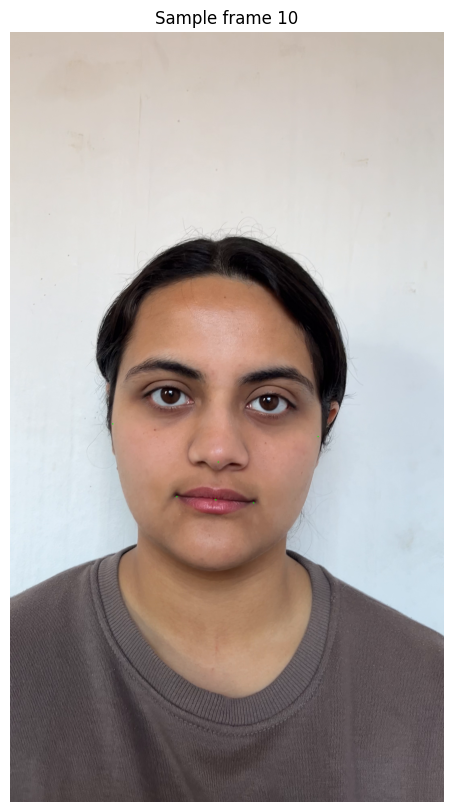

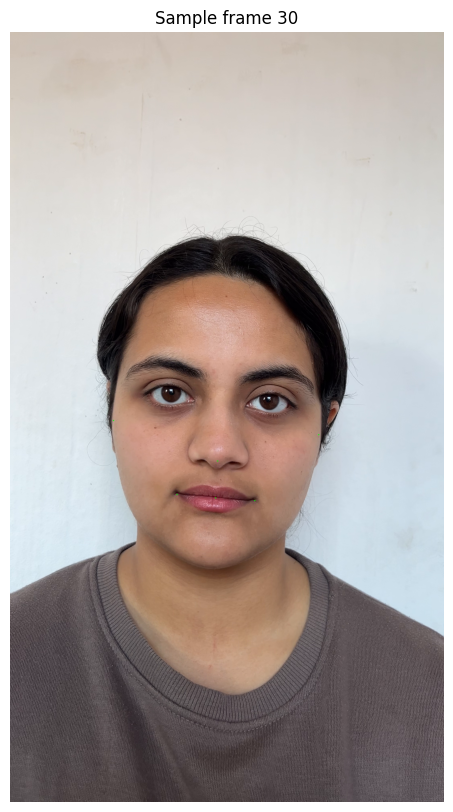

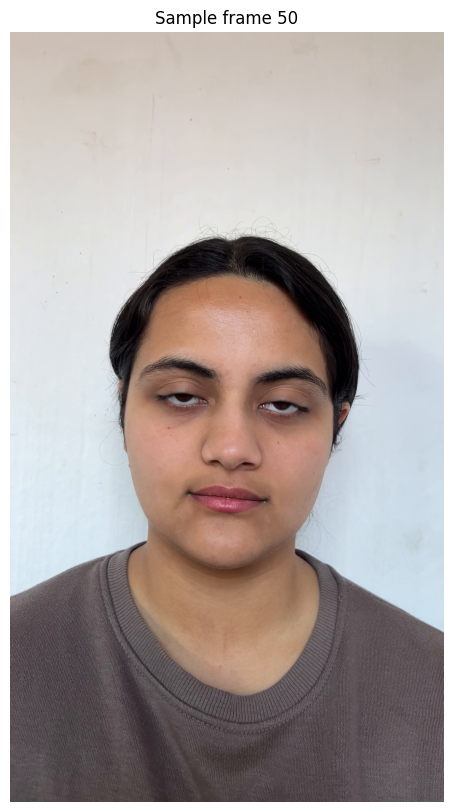

In [10]:
for fid, img in sample_frames:
    plt.figure(figsize=(8, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Sample frame {fid}")
    plt.axis("off")
    plt.show()

In [11]:
def fill_nans(arr):
    arr = np.array(arr, dtype=np.float32)
    if np.all(np.isnan(arr)):
        return arr
    valid = np.where(~np.isnan(arr))[0]
    arr[np.isnan(arr)] = np.interp(np.where(np.isnan(arr))[0], valid, arr[valid])
    return arr

smile_signal = fill_nans(smile_signal)
mouth_open_signal = fill_nans(mouth_open_signal)
head_turn_signal = fill_nans(head_turn_signal)

smile_smooth = moving_average(smile_signal, window_size=7)
mouth_open_smooth = moving_average(mouth_open_signal, window_size=7)
head_turn_smooth = moving_average(head_turn_signal, window_size=7)

print("Signals smoothed.")

Signals smoothed.


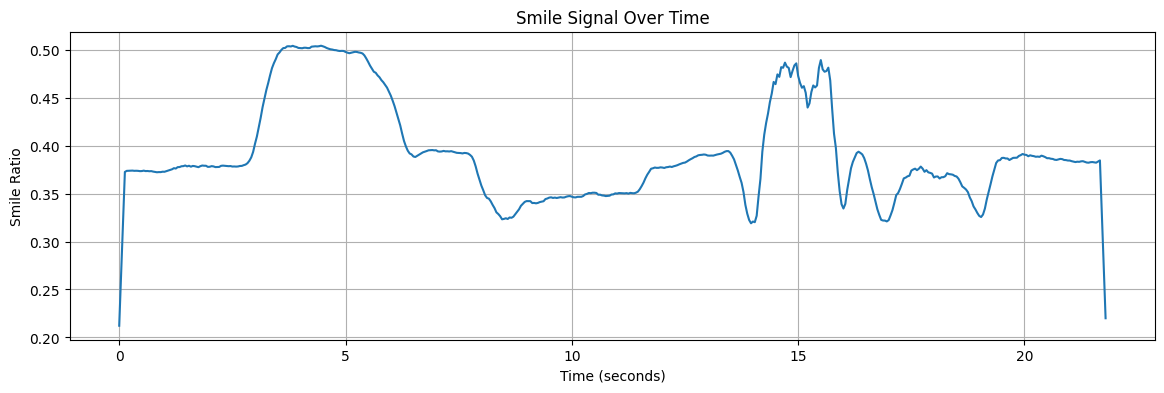

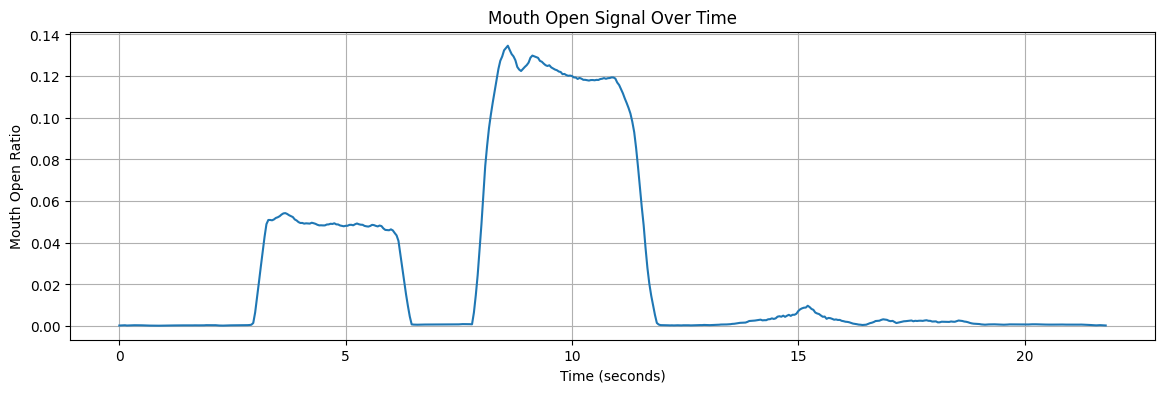

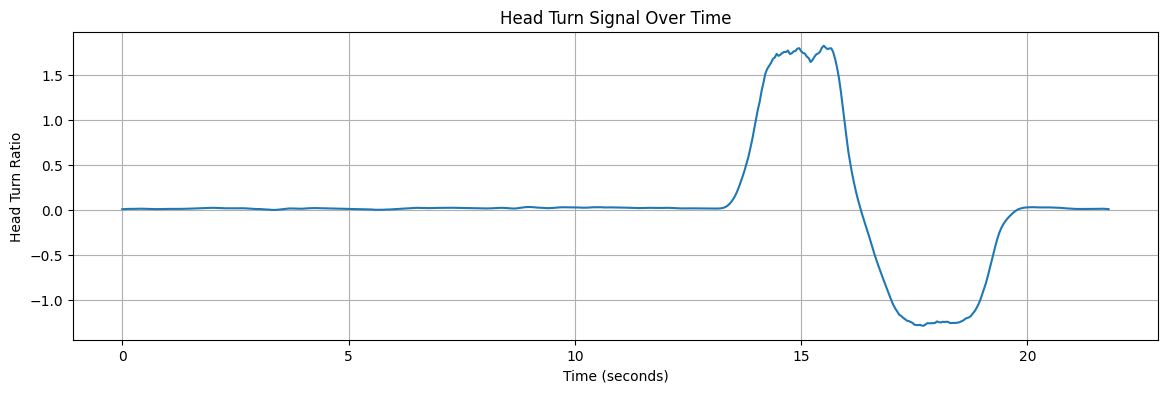

In [12]:
time_axis = np.array(frame_indices) / fps

plt.figure(figsize=(14, 4))
plt.plot(time_axis, smile_smooth)
plt.title("Smile Signal Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Smile Ratio")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(time_axis, mouth_open_smooth)
plt.title("Mouth Open Signal Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Mouth Open Ratio")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(time_axis, head_turn_smooth)
plt.title("Head Turn Signal Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Head Turn Ratio")
plt.grid(True)
plt.show()

In [13]:
SMILE_THRESHOLD = np.percentile(smile_smooth, 70)
MOUTH_OPEN_THRESHOLD = np.percentile(mouth_open_smooth, 75)
HEAD_LEFT_THRESHOLD = -0.02
HEAD_RIGHT_THRESHOLD = 0.02

print("SMILE_THRESHOLD:", SMILE_THRESHOLD)
print("MOUTH_OPEN_THRESHOLD:", MOUTH_OPEN_THRESHOLD)
print("HEAD_LEFT_THRESHOLD:", HEAD_LEFT_THRESHOLD)
print("HEAD_RIGHT_THRESHOLD:", HEAD_RIGHT_THRESHOLD)

SMILE_THRESHOLD: 0.39174148823533733
MOUTH_OPEN_THRESHOLD: 0.048415799226079664
HEAD_LEFT_THRESHOLD: -0.02
HEAD_RIGHT_THRESHOLD: 0.02


In [14]:
frame_labels = []

for s, m, h in zip(smile_smooth, mouth_open_smooth, head_turn_smooth):
    labels = []

    if s > SMILE_THRESHOLD:
        labels.append("Smiling")

    if m > MOUTH_OPEN_THRESHOLD:
        labels.append("Mouth Open")

    if h < HEAD_LEFT_THRESHOLD:
        labels.append("Head Left")
    elif h > HEAD_RIGHT_THRESHOLD:
        labels.append("Head Right")

    if not labels:
        labels = ["Neutral"]

    frame_labels.append(labels)

print("Generated labels for all frames.")
print("First 100 labels:", frame_labels[:100])

Generated labels for all frames.
First 100 labels: [['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Head Right'], ['Head Right'], ['Head Right'], ['Head Right'], ['Head Right'], ['Head Right'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Smili

In [15]:
display(Video(output_path, embed=True))

NameError: name 'output_path' is not defined

In [16]:
import os

print("Exists:", os.path.exists(output_path))
print("Size (bytes):", os.path.getsize(output_path) if os.path.exists(output_path) else "File not found")

NameError: name 'output_path' is not defined

In [17]:
from google.colab import files
files.download("annotated_output.mp4")

FileNotFoundError: Cannot find file: annotated_output.mp4

In [18]:
cap = cv2.VideoCapture(video_path)

output_path = "annotated_output.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

frame_id = 0

face_mesh_video = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

keypoint_indices = [LEFT_MOUTH, RIGHT_MOUTH, UPPER_LIP, LOWER_LIP, NOSE_TIP, LEFT_FACE_EDGE, RIGHT_FACE_EDGE]

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h, w, _ = frame.shape
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh_video.process(rgb)

    if results.multi_face_landmarks:
        face_landmarks = results.multi_face_landmarks[0].landmark

        for idx in keypoint_indices:
            pt = get_point(face_landmarks, idx, w, h).astype(int)
            cv2.circle(frame, tuple(pt), 14, (0, 255, 0), -1)

    labels = frame_labels[frame_id]

    y = 120
    cv2.putText(frame, "Detected:", (60, y), cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 255), 6)
    y += 120

    for label in labels:
        cv2.putText(frame, label, (60, y), cv2.FONT_HERSHEY_SIMPLEX, 2.5, (0, 255, 0), 6)
        y += 100

    out.write(frame)
    frame_id += 1

cap.release()
out.release()

print("Annotated video with points saved to:", output_path)

Annotated video with points saved to: annotated_output.mp4


In [19]:
print("Smile signal stats")
print("min:", np.min(smile_smooth))
print("max:", np.max(smile_smooth))
print("mean:", np.mean(smile_smooth))
print("std:", np.std(smile_smooth))

print("\nMouth-open signal stats")
print("min:", np.min(mouth_open_smooth))
print("max:", np.max(mouth_open_smooth))
print("mean:", np.mean(mouth_open_smooth))
print("std:", np.std(mouth_open_smooth))

print("\nHead-turn signal stats")
print("min:", np.min(head_turn_smooth))
print("max:", np.max(head_turn_smooth))
print("mean:", np.mean(head_turn_smooth))
print("std:", np.std(head_turn_smooth))

Smile signal stats
min: 0.21220062885965618
max: 0.5041987299919128
mean: 0.3914581447465989
std: 0.05192385008372412

Mouth-open signal stats
min: 0.00019672543982908661
max: 0.13457718065806798
mean: 0.02757031927747809
std: 0.04282133374133587

Head-turn signal stats
min: -1.2871145009994505
max: 1.821708423750741
mean: 0.0369402845109735
std: 0.6387254371554143


In [20]:
for name, sig in [("Smile", smile_smooth), ("Mouth", mouth_open_smooth), ("Head", head_turn_smooth)]:
    print(f"\n{name} percentiles:")
    for p in [5, 10, 25, 50, 75, 85, 90, 95]:
        print(f"{p}th: {np.percentile(sig, p):.4f}")


Smile percentiles:
5th: 0.3278
10th: 0.3403
25th: 0.3549
50th: 0.3791
75th: 0.3941
85th: 0.4673
90th: 0.4859
95th: 0.5002

Mouth percentiles:
5th: 0.0003
10th: 0.0004
25th: 0.0007
50th: 0.0022
75th: 0.0484
85th: 0.0861
90th: 0.1186
95th: 0.1234

Head percentiles:
5th: -1.2391
10th: -0.8394
25th: 0.0087
50th: 0.0164
75th: 0.0237
85th: 0.0286
90th: 0.6290
95th: 1.7000


In [21]:
head_turn_clipped = np.clip(head_turn_smooth, -0.25, 0.25)

print("Clipped head-turn stats:")
print("min:", np.min(head_turn_clipped))
print("max:", np.max(head_turn_clipped))
print("mean:", np.mean(head_turn_clipped))
print("std:", np.std(head_turn_clipped))

Clipped head-turn stats:
min: -0.25
max: 0.25
mean: 0.007260192940134127
std: 0.128826810155926


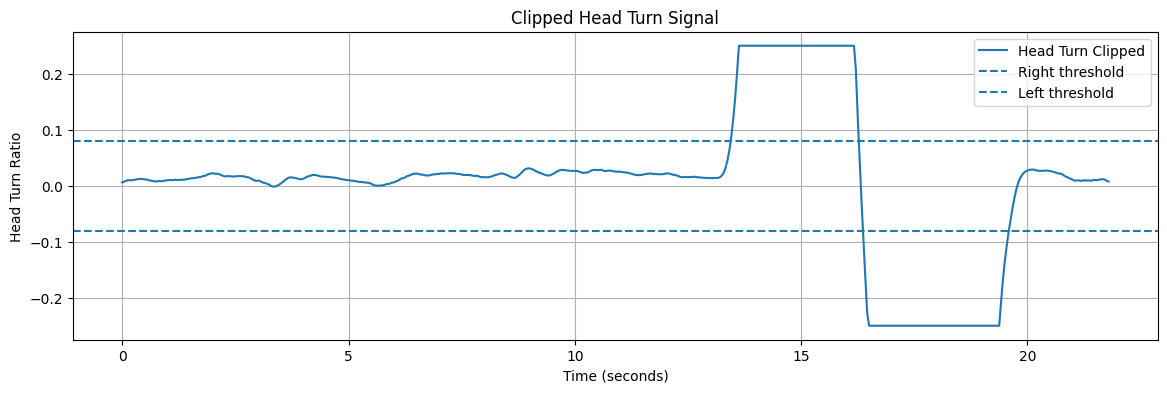

In [22]:
plt.figure(figsize=(14, 4))
plt.plot(time_axis, head_turn_clipped, label="Head Turn Clipped")
plt.axhline(0.08, linestyle="--", label="Right threshold")
plt.axhline(-0.08, linestyle="--", label="Left threshold")
plt.title("Clipped Head Turn Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Head Turn Ratio")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
SMILE_THRESHOLD = np.percentile(smile_smooth, 88)
MOUTH_OPEN_THRESHOLD = np.percentile(mouth_open_smooth, 85)

HEAD_LEFT_THRESHOLD = -0.08
HEAD_RIGHT_THRESHOLD = 0.08

FRONTAL_HEAD_LIMIT = 0.04

print("SMILE_THRESHOLD:", SMILE_THRESHOLD)
print("MOUTH_OPEN_THRESHOLD:", MOUTH_OPEN_THRESHOLD)
print("HEAD_LEFT_THRESHOLD:", HEAD_LEFT_THRESHOLD)
print("HEAD_RIGHT_THRESHOLD:", HEAD_RIGHT_THRESHOLD)
print("FRONTAL_HEAD_LIMIT:", FRONTAL_HEAD_LIMIT)

SMILE_THRESHOLD: 0.4804318227086748
MOUTH_OPEN_THRESHOLD: 0.08608847039618663
HEAD_LEFT_THRESHOLD: -0.08
HEAD_RIGHT_THRESHOLD: 0.08
FRONTAL_HEAD_LIMIT: 0.04


In [24]:
frame_labels = []

for s, m, h in zip(smile_smooth, mouth_open_smooth, head_turn_clipped):
    labels = []

    # Head turn
    if h < HEAD_LEFT_THRESHOLD:
        labels.append("Head Left")
    elif h > HEAD_RIGHT_THRESHOLD:
        labels.append("Head Right")

    # Smile only when face is in front view
    if abs(h) < FRONTAL_HEAD_LIMIT and s > SMILE_THRESHOLD:
        labels.append("Smiling")

    # Mouth open
    if m > MOUTH_OPEN_THRESHOLD:
        labels.append("Mouth Open")

    if not labels:
        labels = ["Neutral"]

    frame_labels.append(labels)

print("Generated labels.")
print("First 10 labels:", frame_labels[:10])

Generated labels.
First 10 labels: [['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral'], ['Neutral']]


In [25]:
def smooth_binary_runs(binary_list, min_run_length=6):
    arr = np.array(binary_list, dtype=int)
    result = arr.copy()

    start = None
    for i in range(len(arr)):
        if arr[i] == 1 and start is None:
            start = i
        elif arr[i] == 0 and start is not None:
            if i - start < min_run_length:
                result[start:i] = 0
            start = None

    if start is not None and len(arr) - start < min_run_length:
        result[start:] = 0

    return result

In [27]:
smile_detected = [1 if abs(h) < FRONTAL_HEAD_LIMIT and s > SMILE_THRESHOLD else 0
                  for s, h in zip(smile_smooth, head_turn_clipped)]

mouth_detected = [1 if m > MOUTH_OPEN_THRESHOLD else 0
                  for m in mouth_open_smooth]

head_left_detected = [1 if h < HEAD_LEFT_THRESHOLD else 0
                      for h in head_turn_clipped]

head_right_detected = [1 if h > HEAD_RIGHT_THRESHOLD else 0
                       for h in head_turn_clipped]

smile_detected = smooth_binary_runs(smile_detected, min_run_length=6)
mouth_detected = smooth_binary_runs(mouth_detected, min_run_length=6)
head_left_detected = smooth_binary_runs(head_left_detected, min_run_length=6)
head_right_detected = smooth_binary_runs(head_right_detected, min_run_length=6)

In [28]:
frame_labels = []

for i in range(len(frame_indices)):
    labels = []

    if head_left_detected[i]:
        labels.append("Head Left")
    elif head_right_detected[i]:
        labels.append("Head Right")

    if smile_detected[i]:
        labels.append("Smiling")

    if mouth_detected[i]:
        labels.append("Mouth Open")

    if not labels:
        labels = ["Neutral"]

    frame_labels.append(labels)

print("Generated labels with stability.")

Generated labels with stability.


In [29]:
cap = cv2.VideoCapture(video_path)

preview_width = 480
preview_height = int((preview_width / width) * height)

output_path = "annotated_preview_updated.mp4"

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (preview_width, preview_height))

frame_id = 0

face_mesh_video = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

keypoint_indices = [LEFT_MOUTH, RIGHT_MOUTH, UPPER_LIP, LOWER_LIP, NOSE_TIP, LEFT_FACE_EDGE, RIGHT_FACE_EDGE]

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h, w, _ = frame.shape
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh_video.process(rgb)

    if results.multi_face_landmarks:
        face_landmarks = results.multi_face_landmarks[0].landmark

        for idx in keypoint_indices:
            pt = get_point(face_landmarks, idx, w, h).astype(int)

            # scale landmark points to resized frame
            pt_resized = (
                int(pt[0] * preview_width / w),
                int(pt[1] * preview_height / h)
            )
            cv2.circle(frame, pt, 14, (0, 255, 0), -1)

    # resize after drawing points
    frame = cv2.resize(frame, (preview_width, preview_height))

    labels = frame_labels[frame_id]

    y = 40
    cv2.putText(frame, "Detected:", (20, y), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
    y += 40

    for label in labels:
        cv2.putText(frame, label, (20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        y += 30

    out.write(frame)
    frame_id += 1

cap.release()
out.release()

print("Updated preview video saved:", output_path)

Updated preview video saved: annotated_preview_updated.mp4


In [30]:
from google.colab import files
files.download("annotated_preview_updated.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
head_turn_clipped = np.clip(head_turn_smooth, -0.25, 0.25)


# Saving everthing until now

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
from google.colab import files

uploaded = files.upload()
video_path = list(uploaded.keys())[0]

print("Uploaded:", video_path)

Saving IMG_2123.mov to IMG_2123 (1).mov
Uploaded: IMG_2123 (1).mov


In [45]:
import shutil

drive_video_path = "/content/drive/MyDrive/facial_project/input_video.mov"

shutil.copy(video_path, drive_video_path)

print("Video saved to Drive:", drive_video_path)

Video saved to Drive: /content/drive/MyDrive/facial_project/input_video.mov


In [46]:
video_path = "/content/drive/MyDrive/facial_project/input_video.mov"

In [47]:
import pandas as pd

df = pd.DataFrame({
    "frame": frame_indices,
    "smile": smile_smooth,
    "mouth_open": mouth_open_smooth,
    "head_turn": head_turn_clipped
})

save_path = "/content/drive/MyDrive/facial_project/signals.csv"

df.to_csv(save_path, index=False)

print("Signals saved to:", save_path)

Signals saved to: /content/drive/MyDrive/facial_project/signals.csv


In [49]:
import os

plots_folder = "/content/drive/MyDrive/facial_project/plots"
os.makedirs(plots_folder, exist_ok=True)

print("Plots folder:", plots_folder)

Plots folder: /content/drive/MyDrive/facial_project/plots


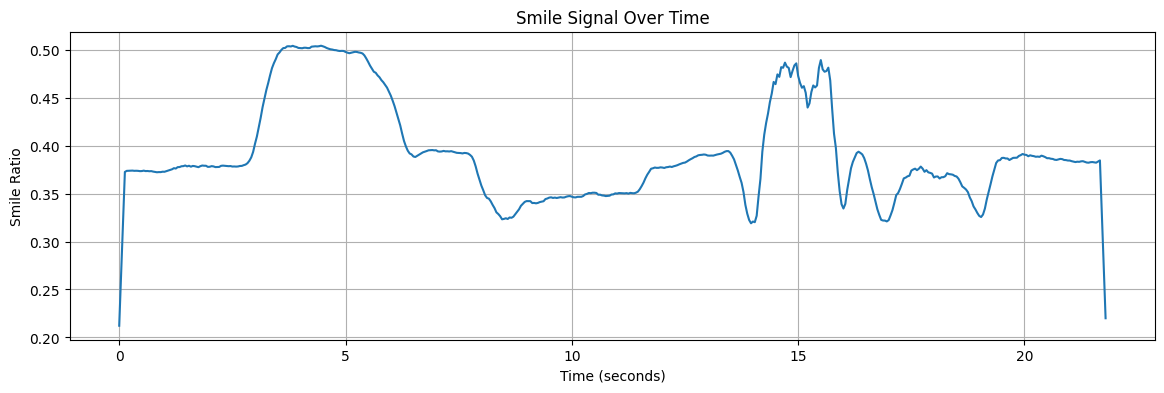

In [50]:
plt.figure(figsize=(14, 4))
plt.plot(time_axis, smile_smooth)
plt.title("Smile Signal Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Smile Ratio")
plt.grid(True)

plt.savefig(f"{plots_folder}/smile_plot.png", bbox_inches='tight')
plt.show()

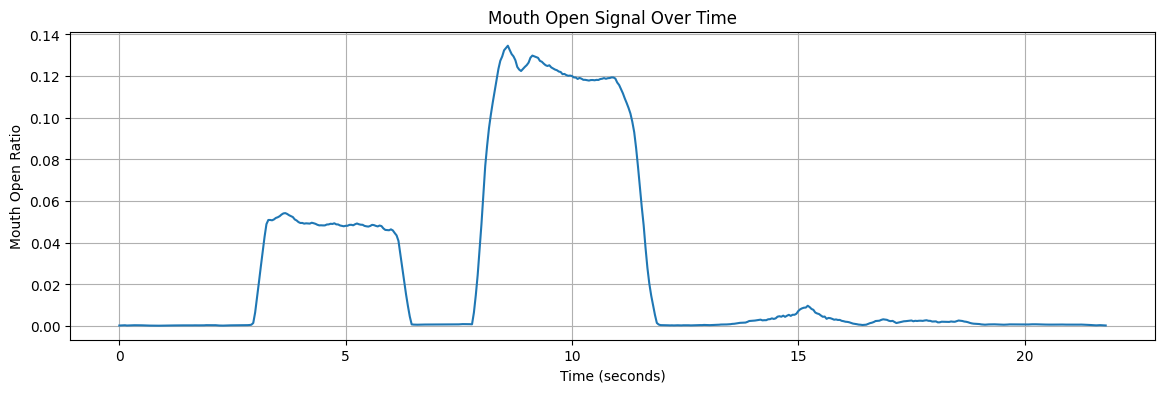

In [51]:
plt.figure(figsize=(14, 4))
plt.plot(time_axis, mouth_open_smooth)
plt.title("Mouth Open Signal Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Mouth Open Ratio")
plt.grid(True)

plt.savefig(f"{plots_folder}/mouth_open_plot.png", bbox_inches='tight')
plt.show()

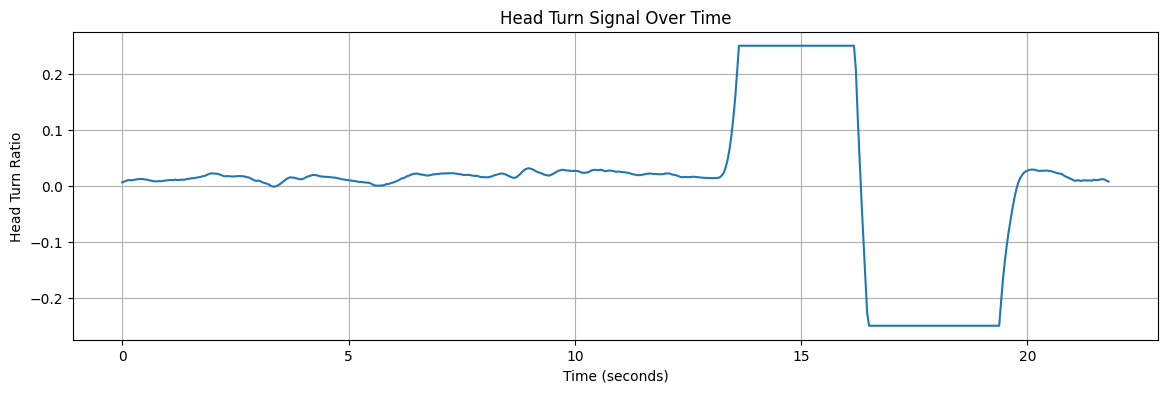

In [52]:
plt.figure(figsize=(14, 4))
plt.plot(time_axis, head_turn_clipped)
plt.title("Head Turn Signal Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Head Turn Ratio")
plt.grid(True)

plt.savefig(f"{plots_folder}/head_turn_plot.png", bbox_inches='tight')
plt.show()

# measurement overlays + visual lines on video

In [53]:
import cv2
import mediapipe as mp
import numpy as np

cap = cv2.VideoCapture(video_path)

preview_width = 480
preview_height = int((preview_width / width) * height)

output_path = "/content/drive/MyDrive/facial_project/annotated_preview_with_measurements.mp4"

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (preview_width, preview_height))

face_mesh_video = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

frame_id = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h, w, _ = frame.shape
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh_video.process(rgb)

    if results.multi_face_landmarks:
        face_landmarks = results.multi_face_landmarks[0].landmark

        # Get points
        left_mouth = get_point(face_landmarks, LEFT_MOUTH, w, h).astype(int)
        right_mouth = get_point(face_landmarks, RIGHT_MOUTH, w, h).astype(int)
        upper_lip = get_point(face_landmarks, UPPER_LIP, w, h).astype(int)
        lower_lip = get_point(face_landmarks, LOWER_LIP, w, h).astype(int)

        nose_tip = get_point(face_landmarks, NOSE_TIP, w, h).astype(int)
        left_face = get_point(face_landmarks, LEFT_FACE_EDGE, w, h).astype(int)
        right_face = get_point(face_landmarks, RIGHT_FACE_EDGE, w, h).astype(int)

        face_center = ((left_face + right_face) / 2).astype(int)

        # key points
        point_color = (0, 255, 0)
        for pt in [left_mouth, right_mouth, upper_lip, lower_lip, nose_tip, left_face, right_face]:
            cv2.circle(frame, tuple(pt), 10, point_color, -1)

        # Smile width line
        cv2.line(frame, tuple(left_mouth), tuple(right_mouth), (255, 0, 0), 6)

        # Mouth openness line
        cv2.line(frame, tuple(upper_lip), tuple(lower_lip), (0, 0, 255), 6)

        # Head turn line (face center to nose)
        cv2.line(frame, tuple(face_center), tuple(nose_tip), (255, 255, 0), 6)

    # Resize
    frame = cv2.resize(frame, (preview_width, preview_height))

    # Scale text positions for preview
    labels = frame_labels[frame_id]

    # Main detection labels
    y = 35
    cv2.putText(frame, "Detected:", (15, y), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)
    y += 35

    for label in labels:
        cv2.putText(frame, label, (15, y), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        y += 28

    # Measurement overlay block
    overlay_y = preview_height - 90

    smile_val = smile_smooth[frame_id]
    mouth_val = mouth_open_smooth[frame_id]
    head_val = head_turn_clipped[frame_id]

    cv2.putText(frame, f"Smile Ratio: {smile_val:.3f}", (15, overlay_y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    cv2.putText(frame, f"Mouth Open Ratio: {mouth_val:.3f}", (15, overlay_y + 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    cv2.putText(frame, f"Head Turn Ratio: {head_val:.3f}", (15, overlay_y + 50),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

    out.write(frame)
    frame_id += 1

cap.release()
out.release()

print("Saved upgraded preview video to:", output_path)

Saved upgraded preview video to: /content/drive/MyDrive/facial_project/annotated_preview_with_measurements.mp4


In [55]:
from google.colab import files
files.download("/content/drive/MyDrive/facial_project/annotated_preview_with_measurements.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>